## Import Necessary Libraries

In [2]:
# Import libraries
import os
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pickle


## Define the Function to Extract Features (MFCC + Delta)

In [4]:
# Function to extract MFCC + delta features from audio files
def extract_features(file_path):
    audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_delta = librosa.feature.delta(mfccs)
    mfccs_delta2 = librosa.feature.delta(mfccs, order=2)
    
    # Concatenate MFCC and delta features
    combined = np.concatenate((mfccs, mfccs_delta, mfccs_delta2), axis=0)
    combined_scaled = np.mean(combined.T, axis=0)
    
    return combined_scaled


## Define the Function to Load Dataset and Extract Features

In [6]:
# Function to load the dataset and extract features for each file
def load_dataset(data_path):
    labels = []
    features = []
    for speaker in os.listdir(data_path):
        speaker_path = os.path.join(data_path, speaker)
        if os.path.isdir(speaker_path):
            for file in os.listdir(speaker_path):
                file_path = os.path.join(speaker_path, file)
                if file_path.endswith('.wav'):
                    features.append(extract_features(file_path))
                    labels.append(speaker)
    return np.array(features), np.array(labels)


## Load the Train, Validation and Test Datasets

In [8]:
# Specify paths to train, validation, and test datasets
train_data_path = r"C:\Users\Hp\Downloads\Speech Recognition System\dataset\train"
validation_data_path = r"C:\Users\Hp\Downloads\Speech Recognition System\dataset\validation"
test_data_path = r"C:\Users\Hp\Downloads\Speech Recognition System\dataset\test"

# Load datasets
X_train, y_train = load_dataset(train_data_path)
X_val, y_val = load_dataset(validation_data_path)
X_test, y_test = load_dataset(test_data_path)

# Print the shape of the datasets
print(f'Training set shape: {X_train.shape}')
print(f'Validation set shape: {X_val.shape}')
print(f'Test set shape: {X_test.shape}')


Training set shape: (588, 120)
Validation set shape: (170, 120)
Test set shape: (83, 120)


## Encode Labels (Speaker Names)

In [10]:
# Encode labels for train, validation, and test
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)


## Visualize Label Distribution in Training Data

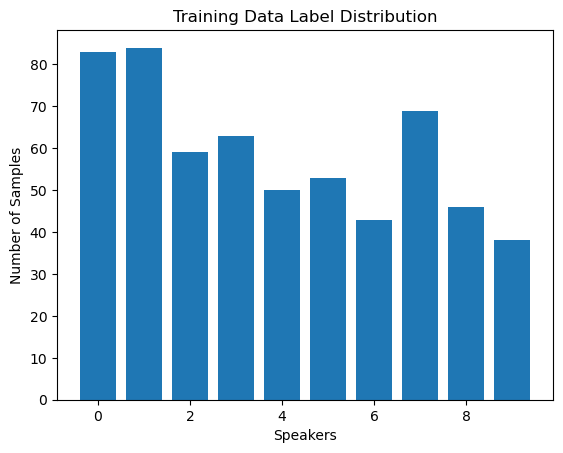

In [12]:
# Visualize label distribution in training data
unique, counts = np.unique(y_train_encoded, return_counts=True)
plt.bar(unique, counts)
plt.title('Training Data Label Distribution')
plt.xlabel('Speakers')
plt.ylabel('Number of Samples')
plt.show()


## Scale the Features

In [14]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


## Initialize and Train the Logistic Regression Model

In [16]:
# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(C=0.5, max_iter=5000)
logistic_model.fit(X_train_scaled, y_train_encoded)


LogisticRegression(C=0.5, max_iter=5000)

## Evaluate Model on Validation and Test Sets

In [18]:
# Evaluate model on validation set
y_val_pred = logistic_model.predict(X_val_scaled)
val_acc = accuracy_score(y_val_encoded, y_val_pred)
print(f'Validation accuracy: {val_acc * 100:.2f}%')

# Evaluate model on test set
y_test_pred = logistic_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test_encoded, y_test_pred)
print(f'Test accuracy: {test_acc * 100:.2f}%')


Validation accuracy: 90.00%
Test accuracy: 84.34%


## Plot Confusion Matrix for the Test Set

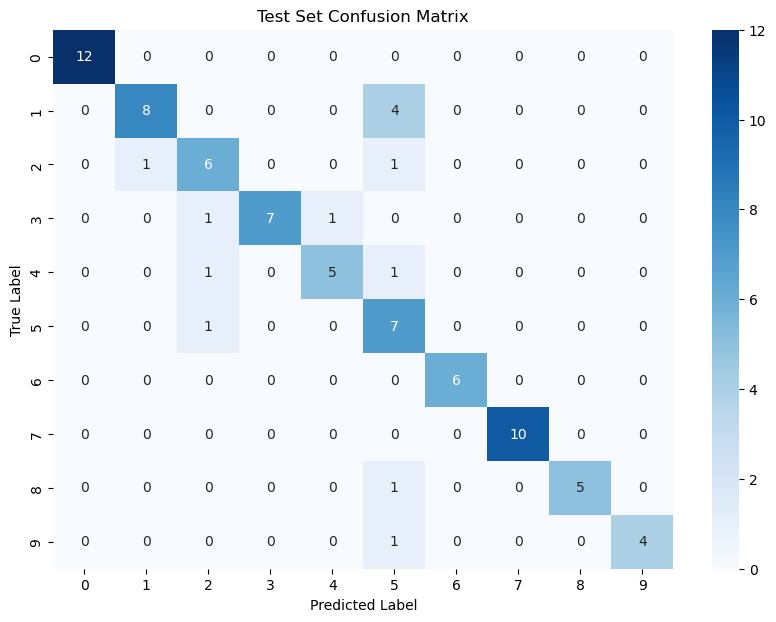

In [20]:
# Plot Confusion Matrix for test set
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Test Set Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## Define the Prediction Function and Test the Prediction Function on a New Audio File

In [37]:
# Function to predict speaker for a new audio file
def predict_speaker(file_path, model, label_encoder, scaler):
    new_feature = extract_features(file_path)
    new_feature_scaled = scaler.transform([new_feature])  # Apply scaling
    prediction = model.predict(new_feature_scaled)
    predicted_speaker = label_encoder.inverse_transform(prediction)
    return predicted_speaker[0]

# Path to a new .wav file for testing
new_wav_file = r"C:\Users\Hp\Downloads\Speech Recognition System\dataset\test\Speaker_0007\Speaker_0007_00060.wav"
predicted_speaker = predict_speaker(new_wav_file, logistic_model, label_encoder, scaler)
print(f'The predicted speaker for {new_wav_file} is: {predicted_speaker}')

The predicted speaker for C:\Users\Hp\Downloads\Speech Recognition System\dataset\test\Speaker_0007\Speaker_0007_00060.wav is: Speaker_0007


## Save the Model Using Pickle

In [39]:
# Save the trained model to a file
model_save_path = r"C:\Users\Hp\Downloads\Speech Recognition System\saved_model_speech_recognition_logistic_regression.pkl"
with open(model_save_path, 'wb') as file:
    pickle.dump(logistic_model, file)
print(f"Model saved to {model_save_path}")

Model saved to C:\Users\Hp\Downloads\Speech Recognition System\saved_model_speech_recognition_logistic_regression.pkl
